# ScienceQA Results Visualizations
This notebook generates visualizations for the final report based on the experimental runs in `info/ablations.md` and the loss logs in `models/training_metrics.csv`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Set style for academic charts
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

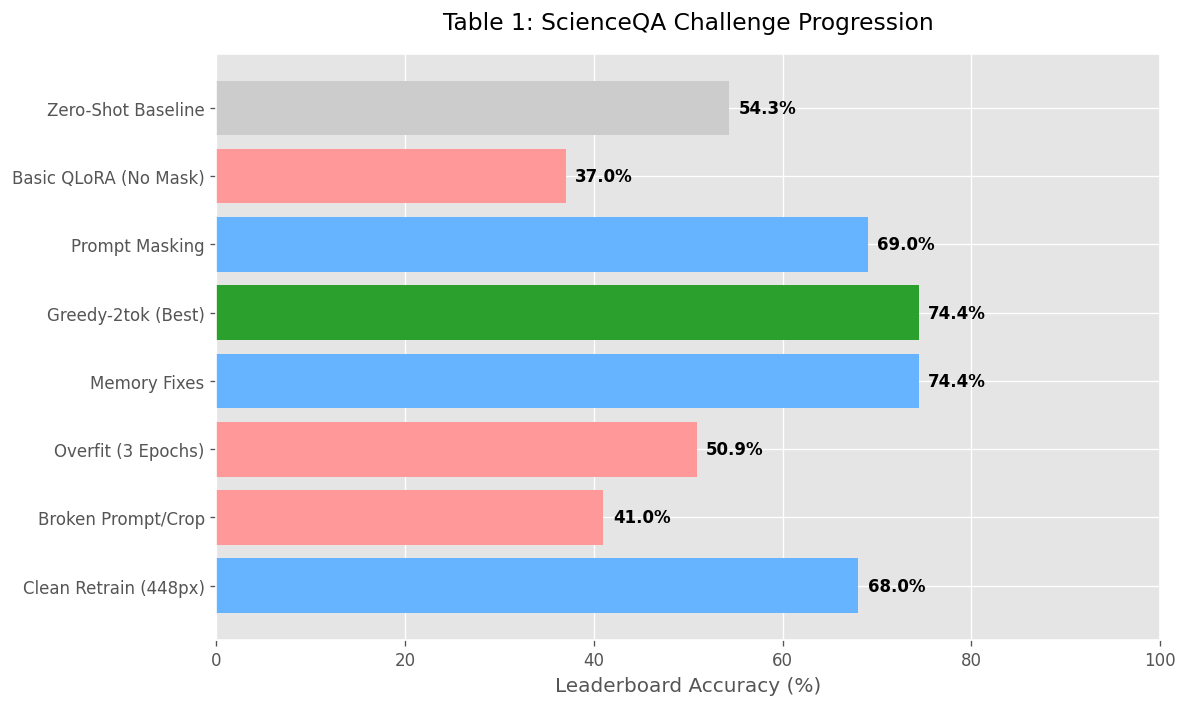

In [6]:
# Leaderboard Accuracies from Ablations
runs = [
    "Zero-Shot Baseline",
    "Basic QLoRA (No Mask)",
    "Prompt Masking",
    "Greedy-2tok (Best)",
    "Memory Fixes",
    "Overfit (3 Epochs)",
    "Broken Prompt/Crop",
    "Clean Retrain (448px)"
]

accuracies = [54.3, 37.0, 69.0, 74.4, 74.4, 50.9, 41.0, 68.0]
colors = ['#cccccc', '#ff9999', '#66b3ff', '#2ca02c', '#66b3ff', '#ff9999', '#ff9999', '#66b3ff']

plt.figure(figsize=(10, 6))
bars = plt.barh(runs[::-1], accuracies[::-1], color=colors[::-1])

plt.xlabel('Leaderboard Accuracy (%)', fontsize=12)
plt.title('Table 1: ScienceQA Challenge Progression', fontsize=14, pad=15)
plt.xlim(0, 100)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width}%', 
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_progression.png')
plt.show()

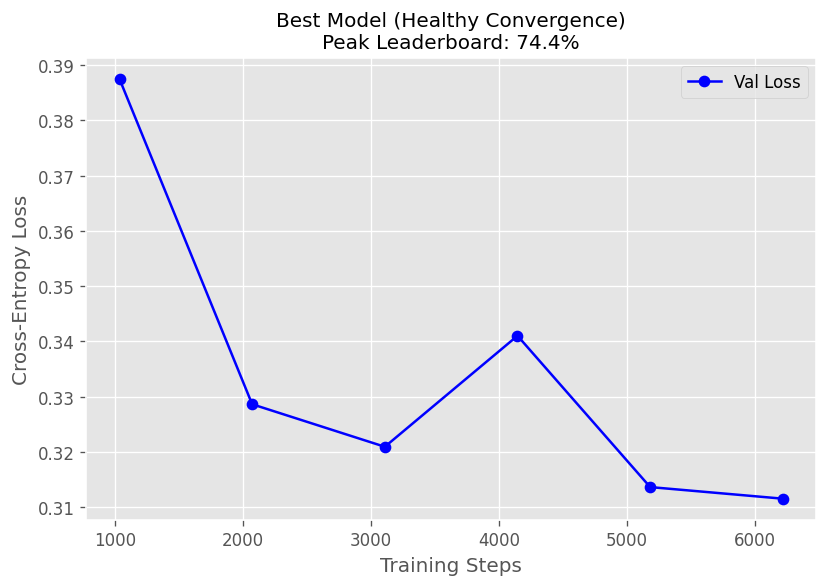

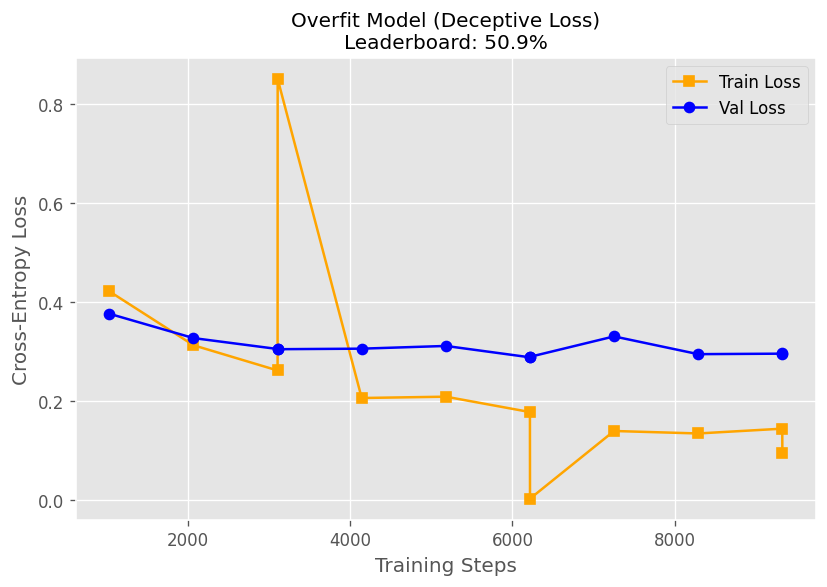

In [7]:
# Read training metrics
metrics_df = pd.read_csv("models/training_metrics.csv")

# The best model: 20260426_233953
# The overfit model: 20260429_183205

best_model_df = metrics_df[metrics_df["Model Name"] == "20260426_233953"].copy()
overfit_model_df = metrics_df[metrics_df["Model Name"] == "20260429_183205"].copy()

# Add a cumulative step counter for plotting
def add_cumulative_steps(df):
    df = df[df["Step"] != "Final"].copy()
    df["Step"] = pd.to_numeric(df["Step"])
    # 3108 steps per epoch
    df["Cumulative Step"] = (df["Epoch"] - 1) * 3108 + df["Step"]
    return df

best_model_df = add_cumulative_steps(best_model_df)
overfit_model_df = add_cumulative_steps(overfit_model_df)

# Plot Best Model (Healthy)
plt.figure(figsize=(7, 5))
plt.plot(best_model_df["Cumulative Step"], best_model_df["Val Loss"], marker="o", color="blue", label="Val Loss")
plt.title("Best Model (Healthy Convergence)\nPeak Leaderboard: 74.4%", fontsize=12)
plt.xlabel("Training Steps")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.savefig("healthy_loss_curve.png")
plt.show()

# Plot Overfit Model
plt.figure(figsize=(7, 5))
plt.plot(overfit_model_df["Cumulative Step"], overfit_model_df["Train Loss"], marker="s", color="orange", label="Train Loss")
plt.plot(overfit_model_df["Cumulative Step"], overfit_model_df["Val Loss"], marker="o", color="blue", label="Val Loss")
plt.title("Overfit Model (Deceptive Loss)\nLeaderboard: 50.9%", fontsize=12)
plt.xlabel("Training Steps")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.savefig("overfit_loss_curve.png")
plt.show()